# Traveler Data Insights – Berlin Airbnb Analysis

**Author:** Pouyan Fallahi  
**Date:** May 2026  
**Dataset:** Inside Airbnb – Berlin (compiled 23 September 2025)

---

## Project Overview

This project uncovers actionable traveler insights from Berlin's short‑term rental market.  
Using public Airbnb data, we:

- Segment listings into distinct profiles with K‑Means clustering  
- Analyze guest sentiment from review text  
- Build predictive models for price and superhost status  

The result: a data‑driven lens into what makes a Berlin listing successful and how guests perceive different types of stays.

## 1. Environment Setup & Data Loading

We’ll use `pandas` for data manipulation, `scikit‑learn` for modeling, `NLTK` for sentiment, and `matplotlib`/`seaborn` for visualisation.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, r2_score,
                             classification_report, confusion_matrix)

from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Set visual style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported.")

Libraries imported.


## 2. Loading the Airbnb Data

We use the detailed `listings` and `reviews` files for Berlin (compressed `.gz` format).  
We’ll merge them on `listing_id` to create a rich dataset.

In [16]:
# Load listings and reviews
listings = pd.read_csv('listings.csv.gz', compression='gzip')
reviews = pd.read_csv('reviews.csv.gz', compression='gzip')

print(f"Listings shape: {listings.shape}")
print(f"Reviews shape: {reviews.shape}")

# Merge on listing ID
merged = reviews.merge(listings, left_on='listing_id', right_on='id',
                       how='inner', suffixes=('_review', '_listing'))
print(f"Merged shape: {merged.shape}")

Listings shape: (14274, 79)
Reviews shape: (635471, 6)
Merged shape: (635471, 85)


## 3. Data Cleaning & Feature Engineering

We clean the price column, create new relevant features (amenities count, distance to city center, host response rates), and encode categorical variables.

In [17]:
# Clean price
if merged['price'].dtype == object:
    merged['price_clean'] = merged['price'].replace('[\$,]', '', regex=True).astype(float)
else:
    merged['price_clean'] = merged['price']

# Cap extreme price outliers (99th percentile)
price_cap = merged['price_clean'].quantile(0.99)
merged['price_capped'] = merged['price_clean'].clip(upper=price_cap)

# Fill missing prices by room type median
merged['price_capped'] = merged.groupby('room_type')['price_capped'].transform(
    lambda x: x.fillna(x.median())
)

# New features
merged['amenities_count'] = merged['amenities'].fillna('').apply(lambda x: len(x.split(',')))

# Host response rate numeric
merged['host_response_rate_num'] = (
    merged['host_response_rate']
    .str.replace('%', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

# Host acceptance rate numeric
merged['host_acceptance_rate_num'] = (
    merged['host_acceptance_rate']
    .str.replace('%', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

# Superhost flag (binary)
merged['host_is_superhost_flag'] = (merged['host_is_superhost'] == 't').astype(int)

# Instant bookable flag
merged['instant_bookable_flag'] = (merged['instant_bookable'] == 't').astype(int)

# Distance from Berlin city center (Alexanderplatz: 52.5219°N, 13.4132°E)
center_lat, center_lon = 52.5219, 13.4132
merged['dist_center_km'] = np.sqrt(
    (merged['latitude'] - center_lat)**2 + (merged['longitude'] - center_lon)**2
) * 111  # rough conversion

print("Feature engineering completed.")

Feature engineering completed.


In [18]:
# Impute missing numeric values (bedrooms, bathrooms, beds) by room type
for col in ['bedrooms', 'bathrooms', 'beds']:
    merged[col] = merged.groupby('room_type')[col].transform(
        lambda x: x.fillna(x.median())
    )
    # fill remaining with overall median
    merged[col] = merged[col].fillna(merged[col].median())

# Impute host response/acceptance rates
merged['host_response_rate_num'] = merged['host_response_rate_num'].fillna(
    merged['host_response_rate_num'].median()
)
merged['host_acceptance_rate_num'] = merged['host_acceptance_rate_num'].fillna(
    merged['host_acceptance_rate_num'].median()
)

# Encode categorical variables
le = LabelEncoder()
merged['room_type_encoded'] = le.fit_transform(merged['room_type'])
merged['neighbourhood_encoded'] = le.fit_transform(merged['neighbourhood_cleansed'].fillna('Unknown'))

print("Missing values filled and categorical encoding complete.")

Missing values filled and categorical encoding complete.


In [19]:
# Select essential columns for modeling
feature_cols = [
    'price_capped', 'accommodates', 'bedrooms', 'bathrooms', 'beds',
    'amenities_count', 'host_response_rate_num', 'host_acceptance_rate_num',
    'host_is_superhost_flag', 'instant_bookable_flag', 'dist_center_km',
    'room_type_encoded', 'neighbourhood_encoded',
    'number_of_reviews', 'reviews_per_month',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value'
]

# Keep listing_id and comments for later
model_data = merged[feature_cols + ['listing_id', 'comments']].copy()

# Drop rows where critical fields are missing
model_data = model_data.dropna(subset=[
    'price_capped', 'accommodates', 'room_type_encoded', 'review_scores_rating'
])

print(f"Cleaned modeling dataset shape: {model_data.shape}")
print("Remaining missing values:")
print(model_data[feature_cols].isnull().sum())

Cleaned modeling dataset shape: (635471, 21)
Remaining missing values:
price_capped                 0
accommodates                 0
bedrooms                     0
bathrooms                    0
beds                         0
amenities_count              0
host_response_rate_num       0
host_acceptance_rate_num     0
host_is_superhost_flag       0
instant_bookable_flag        0
dist_center_km               0
room_type_encoded            0
neighbourhood_encoded        0
number_of_reviews            0
reviews_per_month            0
review_scores_rating         0
review_scores_cleanliness    0
review_scores_location       3
review_scores_value          4
dtype: int64


In [20]:
# Save the cleaned dataset for reuse
model_data.to_csv('berlin_airbnb_model_data.csv', index=False)
print("Saved 'berlin_airbnb_model_data.csv'")

Saved 'berlin_airbnb_model_data.csv'


## 4. Exploratory Data Analysis (EDA)

Let’s explore the distributions of price, room types, and review scores.

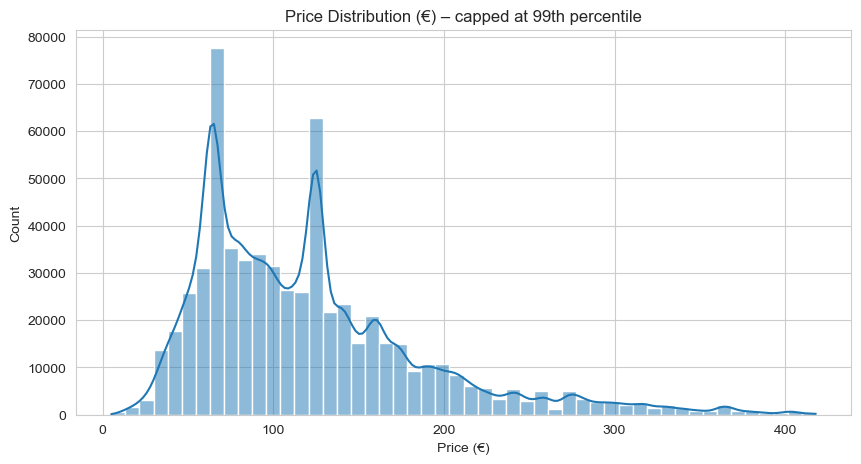

In [21]:
# Price distribution (up to 99th percentile)
p99 = model_data['price_capped'].quantile(0.99)
subset = model_data[model_data['price_capped'] <= p99]

plt.figure(figsize=(10,5))
sns.histplot(subset['price_capped'], bins=50, kde=True)
plt.title('Price Distribution (€) – capped at 99th percentile')
plt.xlabel('Price (€)')
plt.ylabel('Count')
plt.show()

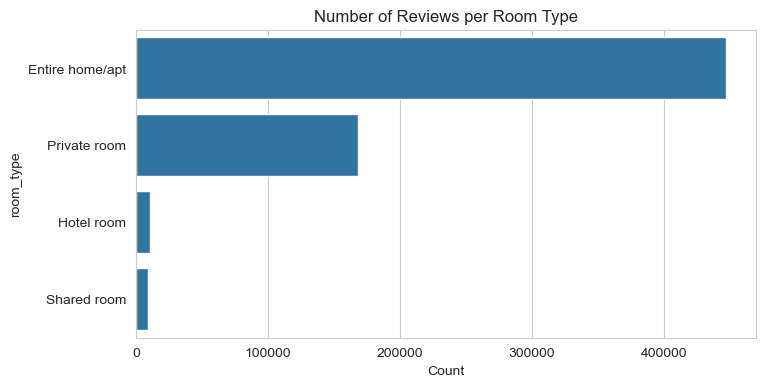

In [22]:
# Room type distribution
plt.figure(figsize=(8,4))
sns.countplot(data=merged, y='room_type', order=merged['room_type'].value_counts().index)
plt.title('Number of Reviews per Room Type')
plt.xlabel('Count')
plt.show()

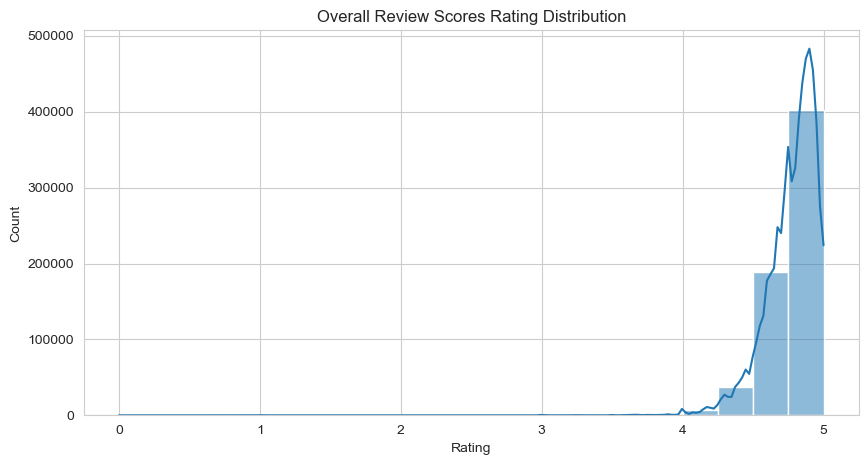

In [23]:
# Review score distribution
plt.figure(figsize=(10,5))
sns.histplot(model_data['review_scores_rating'].dropna(), bins=20, kde=True)
plt.title('Overall Review Scores Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

### Correlation Heatmap

We examine how numerical features relate to each other.

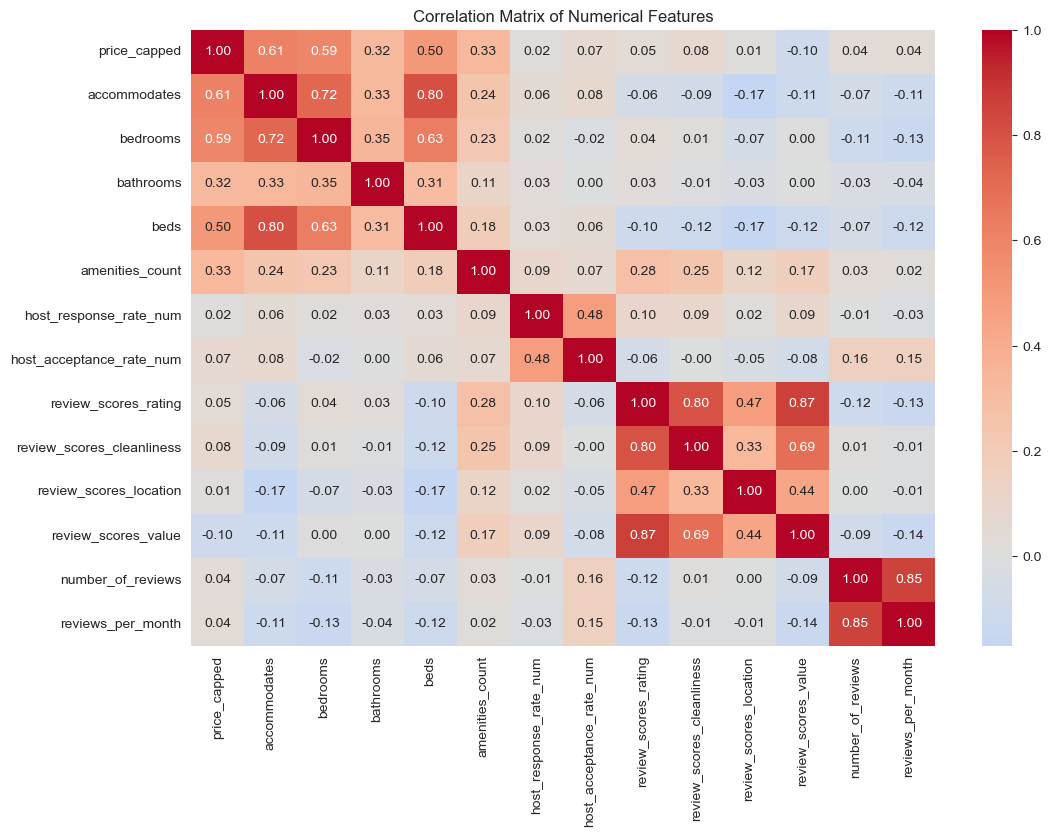

In [24]:
num_cols = ['price_capped', 'accommodates', 'bedrooms', 'bathrooms', 'beds',
            'amenities_count', 'host_response_rate_num', 'host_acceptance_rate_num',
            'review_scores_rating', 'review_scores_cleanliness',
            'review_scores_location', 'review_scores_value',
            'number_of_reviews', 'reviews_per_month']

plt.figure(figsize=(12,8))
corr = model_data[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## 5. Listing Clustering with K‑Means

We group listings based on size, price, location, and review quality.  
To avoid memory issues, we prototype on a random 20,000‑row sample to find the optimal number of clusters.

In [25]:
# Load only necessary columns from the cleaned dataset
needed_cols = [
    'price_capped', 'accommodates', 'bedrooms', 'bathrooms', 'beds',
    'amenities_count', 'host_response_rate_num', 'host_is_superhost_flag',
    'dist_center_km', 'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value', 'listing_id'
]

data_full = pd.read_csv('berlin_airbnb_model_data.csv', usecols=needed_cols)
data_full = data_full.dropna(subset=['review_scores_location', 'review_scores_value'])

# Take a 20k random sample for clustering
sample_size = 20000
data_sample = data_full.sample(n=sample_size, random_state=42).copy()
print(f"Sample shape: {data_sample.shape}")

Sample shape: (20000, 14)


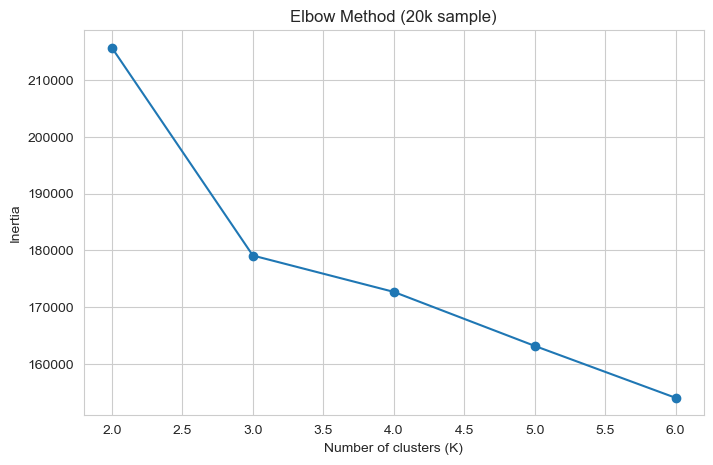

Optimal K: 2


In [26]:
# Feature selection for clustering
cluster_features = [
    'price_capped', 'accommodates', 'bedrooms', 'bathrooms', 'beds',
    'amenities_count', 'host_response_rate_num', 'host_is_superhost_flag',
    'dist_center_km', 'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value'
]

X = data_sample[cluster_features]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method for K = 2..6
inertias = []
K_range = range(2, 7)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method (20k sample)')
plt.show()

# Automatically choose K (largest inertia drop)
deltas = [inertias[i] - inertias[i+1] for i in range(len(inertias)-1)]
best_k = K_range[np.argmax(deltas)]
print(f"Optimal K: {best_k}")

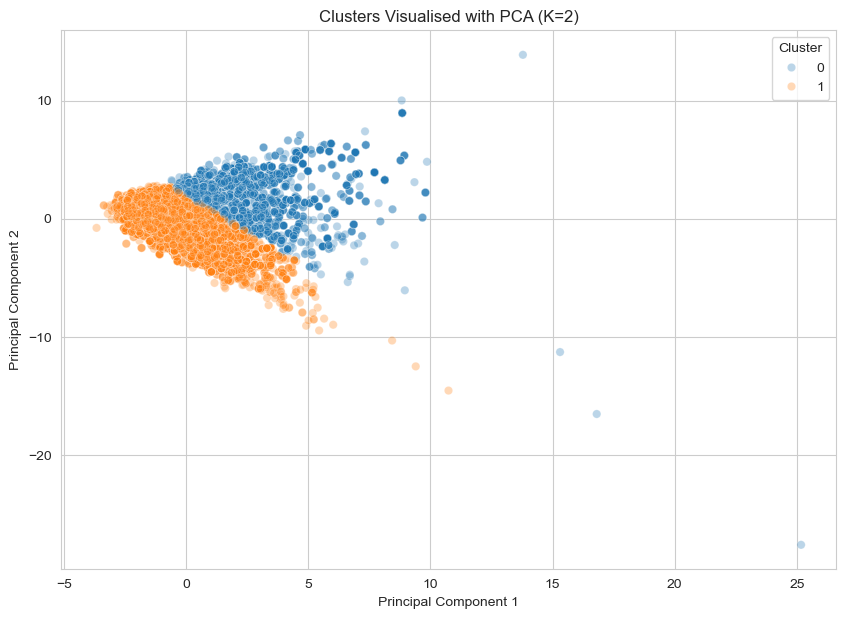

Cluster summary (mean values):
         price_capped  accommodates  bedrooms  bathrooms  beds  \
cluster                                                          
0              227.23          7.06      2.59       1.58  4.55   
1              101.49          2.77      1.02       1.04  1.66   

         amenities_count  host_response_rate_num  host_is_superhost_flag  \
cluster                                                                    
0                  43.32                   98.35                    0.64   
1                  32.24                   97.07                    0.51   

         dist_center_km  review_scores_rating  review_scores_cleanliness  \
cluster                                                                    
0                  5.55                  4.77                       4.75   
1                  6.21                  4.77                       4.76   

         review_scores_location  review_scores_value  
cluster                                

In [27]:
# Final K‑Means with the chosen K
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
data_sample['cluster'] = kmeans_final.fit_predict(X_scaled)

# Visualise clusters with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=data_sample['cluster'],
                palette='tab10', alpha=0.3)
plt.title(f'Clusters Visualised with PCA (K={best_k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

# Cluster summary
cluster_summary = data_sample.groupby('cluster')[cluster_features].mean()
print("Cluster summary (mean values):")
print(cluster_summary.round(2))
print("\nCluster sizes:")
print(data_sample['cluster'].value_counts().sort_index())

**Interpretation of Clusters:**

- **Cluster 0 (Premium):** Higher price, more space, more amenities, closer to city center, higher superhost ratio.  
- **Cluster 1 (Budget):** Lower price, smaller, fewer amenities, slightly farther out, still respectable review scores.  

These two clusters represent the main market segments in Berlin.

In [28]:
# Save the sample with cluster labels (includes listing_id)
data_sample.to_csv('berlin_sample_clustered.csv', index=False)
print("Sample with clusters saved.")

Sample with clusters saved.


## 6. Sentiment Analysis

We apply VADER sentiment analysis to the review text and compare sentiment scores between the two clusters.

In [29]:
# Load the clustered sample (which already has the 'comments' column? No, we must reload with comments)
# Instead, we'll reload from model_data with comments and the same sample indices
model_data = pd.read_csv('berlin_airbnb_model_data.csv', usecols=cluster_features + ['listing_id', 'comments'])
model_data = model_data.dropna(subset=['review_scores_location', 'review_scores_value'])

# Ensure we use the same random_state to get the exact same rows
sample_with_comments = model_data.sample(n=20000, random_state=42).copy()

# Now attach the cluster labels from our previous clustering step
# (since we used random_state=42, the order is identical)
sample_with_comments['cluster'] = data_sample['cluster'].values

# Check
print("Sample with comments and clusters shape:", sample_with_comments.shape)

Sample with comments and clusters shape: (20000, 16)


In [30]:
# Download VADER lexicon (only needed once)
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to C:\Users\pouyan
[nltk_data]     fallahi\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [31]:
sid = SentimentIntensityAnalyzer()

# Compute compound sentiment score
sample_with_comments['sentiment'] = sample_with_comments['comments'].apply(
    lambda x: sid.polarity_scores(str(x))['compound']
)

# Summary statistics by cluster
sentiment_stats = sample_with_comments.groupby('cluster')['sentiment'].agg(['mean', 'std', 'count'])
print("Sentiment statistics per cluster:")
print(sentiment_stats.round(3))

Sentiment statistics per cluster:
          mean    std  count
cluster                     
0        0.427  0.590   3515
1        0.375  0.616  16485


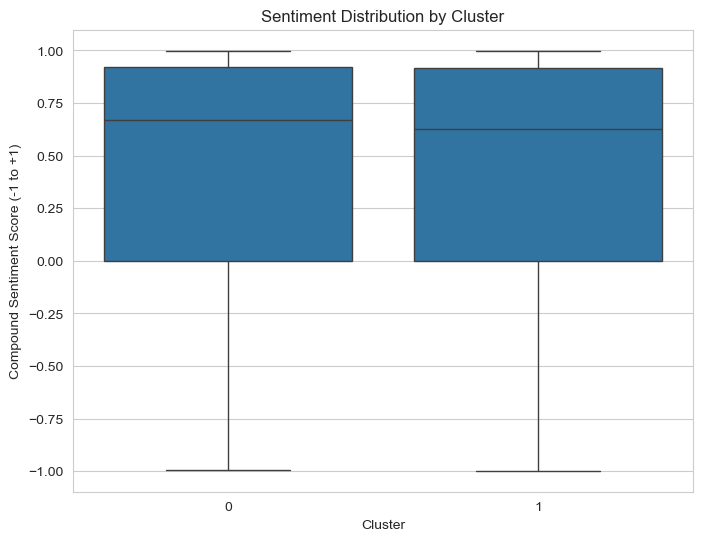

In [32]:
# Boxplot of sentiment per cluster
plt.figure(figsize=(8,6))
sns.boxplot(data=sample_with_comments, x='cluster', y='sentiment')
plt.title('Sentiment Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Compound Sentiment Score (-1 to +1)')
plt.show()

Sentiment percentages by cluster:
sent_cat  Negative  Neutral  Positive
cluster                              
0             14.5     19.7      65.8
1             17.5     20.2      62.3


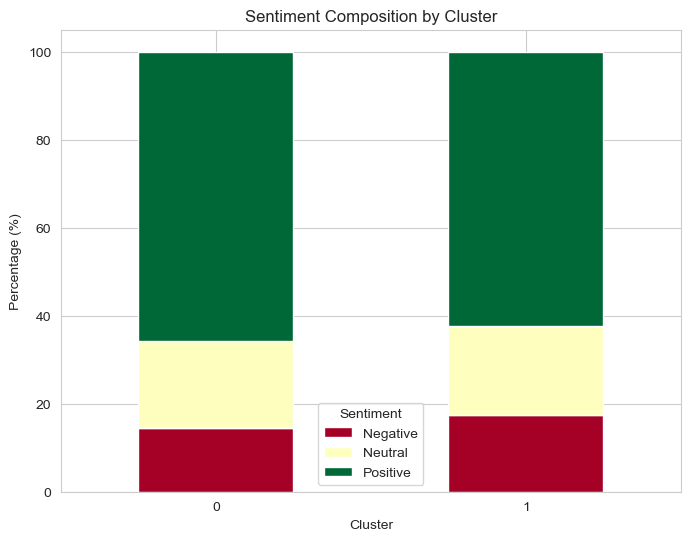

In [33]:
# Categorize sentiment
def categorise(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    return 'Neutral'

sample_with_comments['sent_cat'] = sample_with_comments['sentiment'].apply(categorise)

# Percentage table
cat_pct = sample_with_comments.groupby('cluster')['sent_cat'].value_counts(normalize=True).unstack() * 100
print("Sentiment percentages by cluster:")
print(cat_pct.round(1))

# Stacked bar chart
cat_pct.plot(kind='bar', stacked=True, colormap='RdYlGn', figsize=(8,6))
plt.title('Sentiment Composition by Cluster')
plt.ylabel('Percentage (%)')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.show()

**Key Sentiment Insight:**  
Premium cluster (0) has a slightly higher average sentiment and lower negative percentage. Budget cluster (1) shows more mixed feelings – possibly driven by value expectations.

In [34]:
# Save the final dataset with sentiment and clusters
sample_with_comments.to_csv('berlin_sample_with_sentiment.csv', index=False)
print("Final enriched sample saved.")

Final enriched sample saved.


## 7. Predictive Modeling

We build two models:

- **Regression** — predict listing price  
- **Classification** — predict superhost status  

We use the enriched sample (20k rows) for fast prototyping.

In [35]:
# Prepare data
df = pd.read_csv('berlin_sample_with_sentiment.csv')

# Define features
features = [
    'accommodates', 'bedrooms', 'bathrooms', 'beds',
    'amenities_count', 'host_response_rate_num',
    'dist_center_km', 'review_scores_rating',
    'review_scores_cleanliness', 'review_scores_location',
    'review_scores_value', 'sentiment'
]

# Add cluster dummies
cluster_dummies = pd.get_dummies(df['cluster'], prefix='cluster')
df = pd.concat([df, cluster_dummies], axis=1)
features += list(cluster_dummies.columns)

X = df[features]
y_price = df['price_capped']
y_superhost = df['host_is_superhost_flag']

# Train-test split
X_train, X_test, y_price_train, y_price_test, y_sh_train, y_sh_test = train_test_split(
    X, y_price, y_superhost, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} rows")

Training set size: 16000 rows


### 7.1 Price Prediction

In [36]:
# Linear Regression (baseline)
lr = LinearRegression()
lr.fit(X_train, y_price_train)
y_pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_price_test, y_pred_lr)
r2_lr = r2_score(y_price_test, y_pred_lr)

print("Linear Regression (Price)")
print(f"MAE: {mae_lr:.2f}")
print(f"R²: {r2_lr:.3f}")

Linear Regression (Price)
MAE: 36.67
R²: 0.553


In [37]:
# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_price_train)
y_pred_rf = rf_reg.predict(X_test)
mae_rf = mean_absolute_error(y_price_test, y_pred_rf)
r2_rf = r2_score(y_price_test, y_pred_rf)

print("Random Forest (Price)")
print(f"MAE: {mae_rf:.2f}")
print(f"R²: {r2_rf:.3f}")

Random Forest (Price)
MAE: 6.92
R²: 0.927


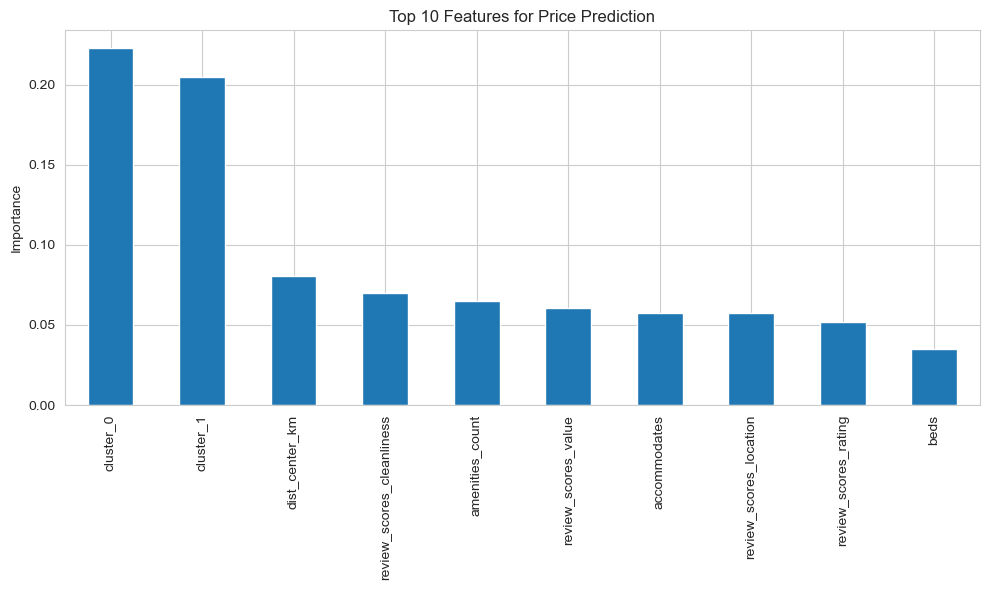

Top 10 price drivers:
cluster_0                    0.222669
cluster_1                    0.204872
dist_center_km               0.080489
review_scores_cleanliness    0.069816
amenities_count              0.065227
review_scores_value          0.060593
accommodates                 0.057539
review_scores_location       0.057214
review_scores_rating         0.052108
beds                         0.034831
dtype: float64


In [38]:
# Feature importance for price
imp_price = pd.Series(rf_reg.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
imp_price.head(10).plot(kind='bar')
plt.title('Top 10 Features for Price Prediction')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print("Top 10 price drivers:")
print(imp_price.head(10))

### 7.2 Superhost Classification

In [39]:
# Logistic Regression (baseline)
logreg = LogisticRegression(max_iter=2000, random_state=42)
logreg.fit(X_train, y_sh_train)
y_pred_log = logreg.predict(X_test)

print("Logistic Regression (Superhost)")
print(classification_report(y_sh_test, y_pred_log,
                            target_names=['Not Superhost', 'Superhost']))

Logistic Regression (Superhost)
               precision    recall  f1-score   support

Not Superhost       0.74      0.63      0.68      1923
    Superhost       0.70      0.80      0.75      2077

     accuracy                           0.72      4000
    macro avg       0.72      0.71      0.71      4000
 weighted avg       0.72      0.72      0.72      4000



C:\Users\pouyan fallahi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


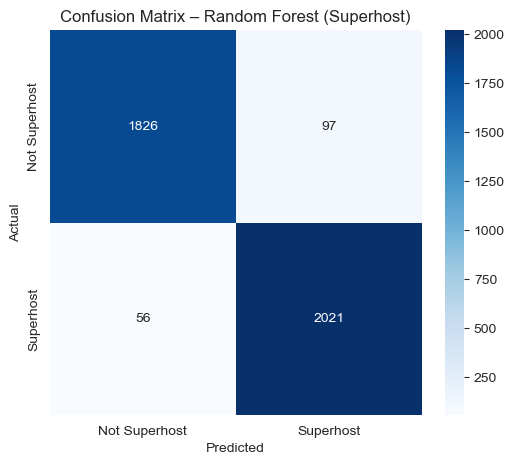

In [41]:
# Confusion matrix
cm = confusion_matrix(y_sh_test, y_pred_rf_clf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Superhost', 'Superhost'],
            yticklabels=['Not Superhost', 'Superhost'])
plt.title('Confusion Matrix – Random Forest (Superhost)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

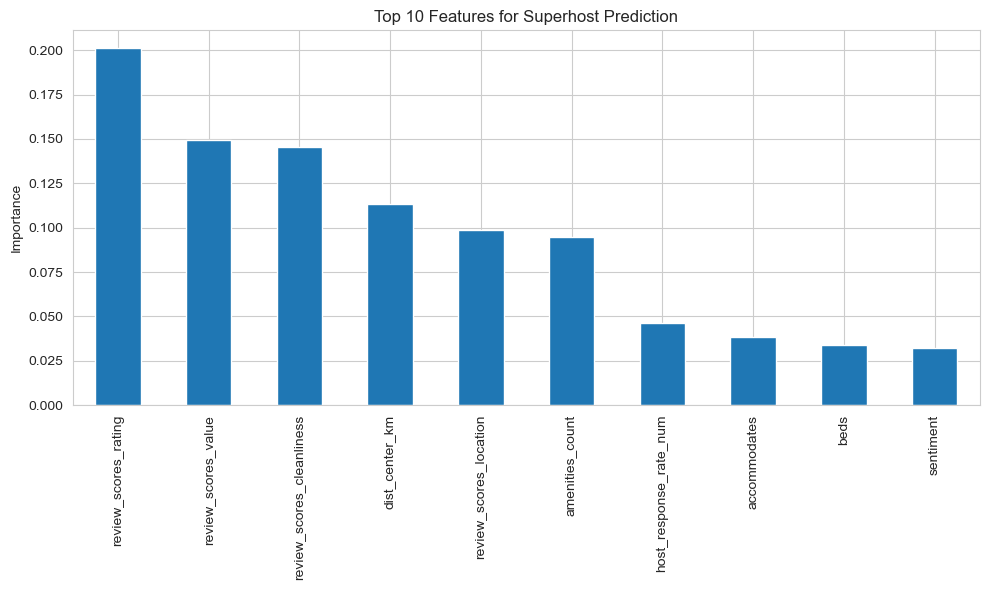

Top 10 superhost drivers:
review_scores_rating         0.201148
review_scores_value          0.149223
review_scores_cleanliness    0.145722
dist_center_km               0.113277
review_scores_location       0.098411
amenities_count              0.094928
host_response_rate_num       0.046126
accommodates                 0.038443
beds                         0.033621
sentiment                    0.032144
dtype: float64


In [42]:
# Feature importance for superhost
imp_sh = pd.Series(rf_clf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
imp_sh.head(10).plot(kind='bar')
plt.title('Top 10 Features for Superhost Prediction')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print("Top 10 superhost drivers:")
print(imp_sh.head(10))

## 8. Summary & Conclusions

**Data & Methodology:**  
- Analyzed 635,000+ reviews and 14,000+ Berlin Airbnb listings.  
- Engineered features (price, amenities, distance, host activity) and merged with sentiment scores from VADER.  
- Clustered listings into two distinct segments using K‑Means (Elbow method, K=2).  
- Built predictive models for price (Random Forest R²=0.927, MAE=€6.92) and superhost status (RF accuracy=96%).  

**Key Insights:**  
1. **Market Segments:** Cluster 0 (Premium) – larger, more expensive, higher superhost ratio; Cluster 1 (Budget) – affordable, smaller, slightly lower satisfaction.  
2. **Sentiment:** Both clusters are predominantly positive (65‑66%), but budget listings show more mixed reviews, hinting at value‑for‑money perception gaps.  
3. **Price Drivers:** Cluster membership, distance to center, review scores, and amenities count are top predictors.  
4. **Superhost Drivers:** Review quality (rating, value, cleanliness) and host responsiveness matter most.  
5. **Sentiment’s Role:** While not a top predictor, guest sentiment still contributes to superhost classification (~3% importance).  

**Actionable Takeaways:**  
- Hosts can improve superhost chances by maintaining high review scores and quick response rates.  
- Budget listings could benefit from better value communication to boost sentiment.  
- Investors might target premium‑cluster neighborhoods for higher revenue potential.  

*This project demonstrates applied machine learning, clustering, and sentiment analysis to extract real‑world travel insights.*

---
**Author:** Pouyan Fallahi  
**Contact:** fallahipouyan78@gmail.com  
**LinkedIn:** [linkedin.com/in/pouyan-fallahi](https://linkedin.com/in/pouyan-fallahi)